In [ ]:
import scanpy as sc

: 

In [ ]:
# --- set project root so all relative paths resolve (run this first, every notebook) ---
import os
os.chdir("/autofs/projects-t3/hussain/scProj/kidney-cancer")
print("cwd:", os.getcwd())

: 

In [ ]:
adata = sc.read_csv('Data/GSM6133746_RCC-BM1-Tumor.count.csv').T
adata

AnnData object with n_obs × n_vars = 4561 × 32738

In [8]:
adata.X.shape

(4561, 32738)

# Doublet removal - optional but preferred

In [8]:
import scvi

In [9]:
adata

AnnData object with n_obs × n_vars = 4561 × 32738

In [10]:
sc.pp.filter_genes(adata, min_cells = 10)

In [11]:
sc.pp.highly_variable_genes(adata, n_top_genes = 2000, subset = True, flavor = 'seurat_v3')

In [12]:
scvi.model.SCVI.setup_anndata(adata)
vae = scvi.model.SCVI(adata)
vae.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/srifai/miniconda3/envs/sc-general-analysis/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/srifai/miniconda3/envs/sc-general-analysis/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=55` in the `DataLoader` to improve performance.


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


In [13]:
solo = scvi.external.SOLO.from_scvi_model(vae)
solo.train()

INFO     Creating doublets, preparing SOLO model.                                                                  


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/srifai/miniconda3/envs/sc-general-analysis/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/srifai/miniconda3/envs/sc-general-analysis/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=55` in the `DataLoader` to improve performance.
/home/srifai/miniconda3/envs/sc-general-analysis/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/da

Training:   0%|          | 0/400 [00:00<?, ?it/s]

Monitored metric validation_loss did not improve in the last 30 records. Best score: 0.207. Signaling Trainer to stop.


In [14]:
df = solo.predict()
df['prediction'] = solo.predict(soft = False)

df.index = df.index.map(lambda x: x[:-2])

df

/home/srifai/miniconda3/envs/sc-general-analysis/lib/python3.11/site-packages/torch/utils/_contextlib.py:124: UserWarning: Prior to scvi-tools 1.1.3, `SOLO.predict` with `soft=True` (the default option) returned logits instead of probabilities. This behavior has since been corrected to return probabilities. The previous behavior can be replicated by passing in `return_logits=True`.
  return func(*args, **kwargs)
/home/srifai/miniconda3/envs/sc-general-analysis/lib/python3.11/site-packages/torch/utils/_contextlib.py:124: UserWarning: Prior to scvi-tools 1.1.3, `SOLO.predict` with `soft=True` (the default option) returned logits instead of probabilities. This behavior has since been corrected to return probabilities. The previous behavior can be replicated by passing in `return_logits=True`.
  return func(*args, **kwargs)


,doublet,singlet,prediction
RCC-BM1-Tumor_AAACCTGCACCAGCAC,0.997781,0.002219,doublet
RCC-BM1-Tumor_AAACCTGCACGGTTTA,0.003957,0.996043,singlet
RCC-BM1-Tumor_AAACCTGCATGGGACA,0.208838,0.791162,singlet
RCC-BM1-Tumor_AAACCTGGTAGCACGA,0.000009,0.999991,singlet
RCC-BM1-Tumor_AAACCTGGTATTACCG,0.002194,0.997806,singlet
...,...,...,...
RCC-BM1-Tumor_TTTGTCACAGGATCGA,0.791154,0.208846,doublet
RCC-BM1-Tumor_TTTGTCACATTCACTT,0.001338,0.998662,singlet
RCC-BM1-Tumor_TTTGTCAGTCTCTCTG,0.000005,0.999995,singlet
RCC-BM1-Tumor_TTTGTCATCAGCTTAG,0.000315,0.999685,singlet


In [15]:
df.groupby('prediction').count()

,doublet,singlet
prediction,,
doublet,680,680
singlet,3881,3881


In [16]:
df['dif'] = df.doublet - df.singlet
df

,doublet,singlet,prediction,dif
RCC-BM1-Tumor_AAACCTGCACCAGCAC,0.997781,0.002219,doublet,0.995563
RCC-BM1-Tumor_AAACCTGCACGGTTTA,0.003957,0.996043,singlet,-0.992085
RCC-BM1-Tumor_AAACCTGCATGGGACA,0.208838,0.791162,singlet,-0.582323
RCC-BM1-Tumor_AAACCTGGTAGCACGA,0.000009,0.999991,singlet,-0.999981
RCC-BM1-Tumor_AAACCTGGTATTACCG,0.002194,0.997806,singlet,-0.995612
...,...,...,...,...
RCC-BM1-Tumor_TTTGTCACAGGATCGA,0.791154,0.208846,doublet,0.582309
RCC-BM1-Tumor_TTTGTCACATTCACTT,0.001338,0.998662,singlet,-0.997324
RCC-BM1-Tumor_TTTGTCAGTCTCTCTG,0.000005,0.999995,singlet,-0.999990
RCC-BM1-Tumor_TTTGTCATCAGCTTAG,0.000315,0.999685,singlet,-0.999370


In [17]:
import seaborn as sns

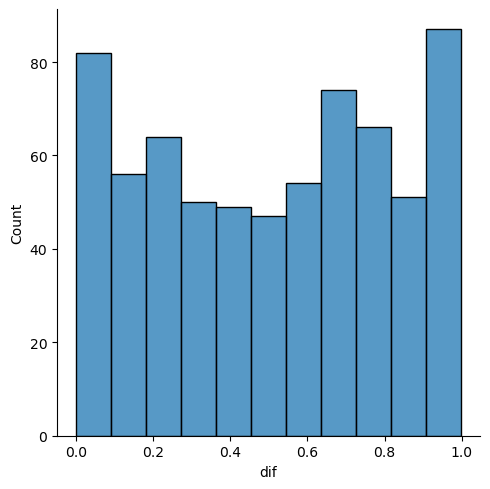

In [18]:
sns.displot(df[df.prediction == 'doublet'], x = 'dif')

In [19]:
doublets = df[(df.prediction == 'doublet') & (df.dif > 1)]
doublets

,doublet,singlet,prediction,dif


In [21]:
adata = sc.read_csv('Data/GSM6133746_RCC-BM1-Tumor.count.csv').T

In [22]:
adata.obs['doublet'] = adata.obs.index.isin(doublets.index)

In [23]:
adata.obs

,doublet
RCC-BM1-Tumor_AAACCTGCACCAGCAC-1,False
RCC-BM1-Tumor_AAACCTGCACGGTTTA-1,False
RCC-BM1-Tumor_AAACCTGCATGGGACA-1,False
RCC-BM1-Tumor_AAACCTGGTAGCACGA-1,False
RCC-BM1-Tumor_AAACCTGGTATTACCG-1,False
...,...
RCC-BM1-Tumor_TTTGTCACAGGATCGA-1,False
RCC-BM1-Tumor_TTTGTCACATTCACTT-1,False
RCC-BM1-Tumor_TTTGTCAGTCTCTCTG-1,False
RCC-BM1-Tumor_TTTGTCATCAGCTTAG-1,False


In [24]:
adata = adata[~adata.obs.doublet]

In [25]:
adata

View of AnnData object with n_obs × n_vars = 4561 × 32738
    obs: 'doublet'

# Preprocessing

In [26]:
adata.var['mt'] = adata.var.index.str.startswith('MT-')

/tmp/ipykernel_1647327/310233584.py:1: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var['mt'] = adata.var.index.str.startswith('MT-')


In [27]:
adata.var

,mt
MIR1302-10,False
FAM138A,False
OR4F5,False
RP11-34P13.7,False
RP11-34P13.8,False
...,...
AC145205.1,False
BAGE5,False
CU459201.1,False
AC002321.2,False


In [28]:
import pandas as pd

In [29]:
ribo_url = "http://software.broadinstitute.org/gsea/msigdb/download_geneset.jsp?geneSetName=KEGG_RIBOSOME&fileType=txt"

In [30]:
ribo_genes = pd.read_table(ribo_url, skiprows=2, header = None)
ribo_genes

,0
0,FAU
1,MRPL13
2,RPL10
3,RPL10A
4,RPL10L
...,...
83,RPS9
84,RPSA
85,RSL24D1
86,RSL24D1P11


In [31]:
adata.var['ribo'] = adata.var_names.isin(ribo_genes[0].values)

In [32]:
adata.obs

,doublet
RCC-BM1-Tumor_AAACCTGCACCAGCAC-1,False
RCC-BM1-Tumor_AAACCTGCACGGTTTA-1,False
RCC-BM1-Tumor_AAACCTGCATGGGACA-1,False
RCC-BM1-Tumor_AAACCTGGTAGCACGA-1,False
RCC-BM1-Tumor_AAACCTGGTATTACCG-1,False
...,...
RCC-BM1-Tumor_TTTGTCACAGGATCGA-1,False
RCC-BM1-Tumor_TTTGTCACATTCACTT-1,False
RCC-BM1-Tumor_TTTGTCAGTCTCTCTG-1,False
RCC-BM1-Tumor_TTTGTCATCAGCTTAG-1,False


In [33]:
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'ribo'], percent_top=None, log1p=False, inplace=True)

In [34]:
adata.var.sort_values('n_cells_by_counts')

,mt,ribo,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts
RP11-563M4.1,False,False,0,0.000000,100.000000,0.0
RP11-292D4.1,False,False,0,0.000000,100.000000,0.0
RP11-292D4.3,False,False,0,0.000000,100.000000,0.0
DYDC1,False,False,0,0.000000,100.000000,0.0
RP11-752L20.5,False,False,0,0.000000,100.000000,0.0
...,...,...,...,...,...,...
RPL10,False,True,4556,30.432800,0.109625,138804.0
B2M,False,False,4556,48.708178,0.109625,222158.0
EEF1A1,False,False,4557,33.019952,0.087700,150604.0
RPL13,False,True,4557,29.765841,0.087700,135762.0


In [35]:
sc.pp.filter_genes(adata, min_cells=3)

In [36]:
adata.var.sort_values('n_cells_by_counts')

,mt,ribo,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,n_cells
USP12-AS2,False,False,3,0.000658,99.934225,3.0,3
WASF3-AS1,False,False,3,0.000658,99.934225,3.0,3
HIST1H4F,False,False,3,0.000658,99.934225,3.0,3
GPR88,False,False,3,0.000658,99.934225,3.0,3
RP11-305E17.6,False,False,3,0.000658,99.934225,3.0,3
...,...,...,...,...,...,...,...
B2M,False,False,4556,48.708178,0.109625,222158.0,4556
RPL10,False,True,4556,30.432800,0.109625,138804.0,4556
EEF1A1,False,False,4557,33.019952,0.087700,150604.0,4557
RPL13,False,True,4557,29.765841,0.087700,135762.0,4557


In [37]:
adata.obs.sort_values('n_genes_by_counts')

,doublet,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo
RCC-BM1-Tumor_GCACTCTCACAGACAG-1,False,123,2076.0,1897.0,91.377655,10.0,0.481696
RCC-BM1-Tumor_CGACCTTGTCCTAGCG-1,False,198,1560.0,1269.0,81.346153,70.0,4.487180
RCC-BM1-Tumor_ACCTTTAGTTGTGGCC-1,False,226,2299.0,15.0,0.652458,586.0,25.489342
RCC-BM1-Tumor_GGCTCGACAAGCCATT-1,False,290,2676.0,2146.0,80.194321,29.0,1.083707
RCC-BM1-Tumor_TGCTACCTCTGTCTCG-1,False,300,1903.0,1382.0,72.622177,60.0,3.152917
...,...,...,...,...,...,...,...
RCC-BM1-Tumor_ATCCGAAAGGAGTACC-1,False,4283,22302.0,886.0,3.972738,5432.0,24.356560
RCC-BM1-Tumor_ACGGAGAGTCAAGCGA-1,False,4289,26201.0,771.0,2.942636,8517.0,32.506390
RCC-BM1-Tumor_GACGGCTGTTTAGGAA-1,False,4771,32996.0,1185.0,3.591345,7931.0,24.036247
RCC-BM1-Tumor_GTATTCTCACGGCCAT-1,False,5281,29882.0,4027.0,13.476340,5343.0,17.880329


In [38]:
sc.pp.filter_cells(adata, min_genes=200)

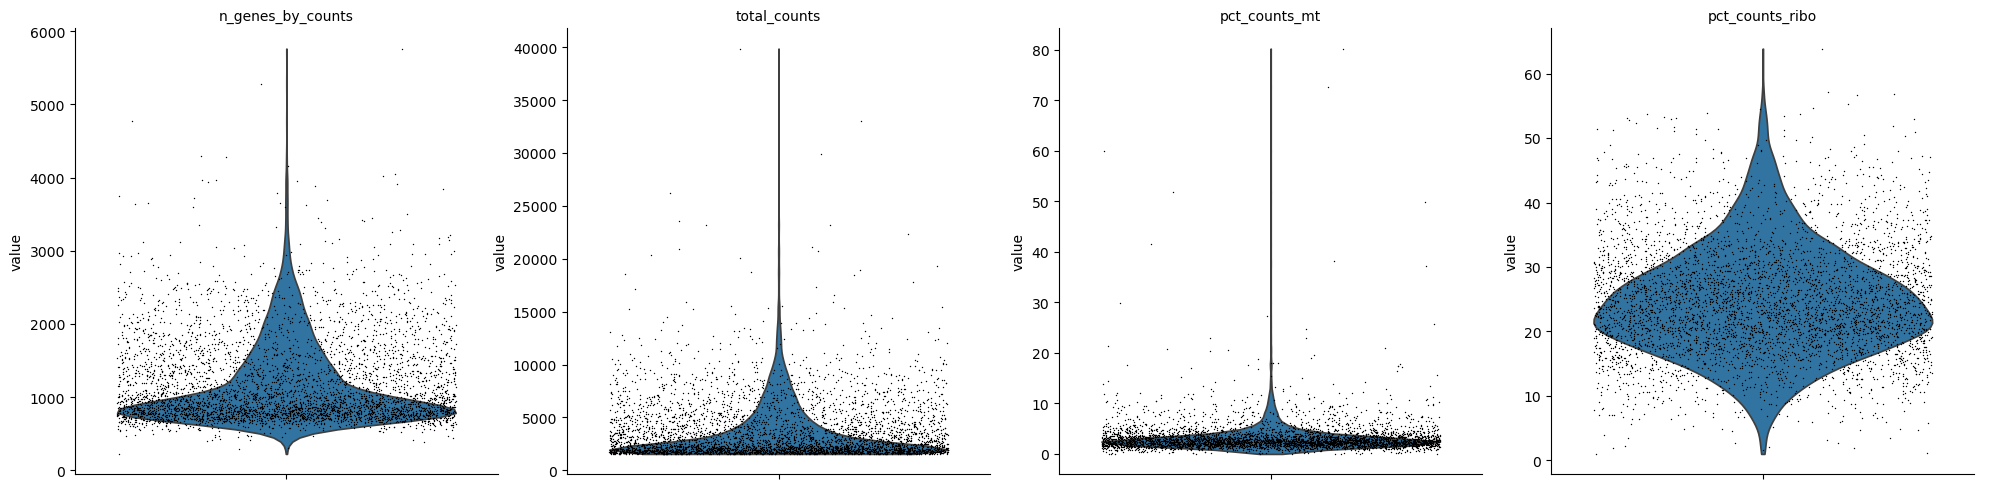

In [39]:
adata.var_names_make_unique()

sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo'], 
             jitter=0.4, multi_panel=True)

In [40]:
import numpy as np

In [41]:
upper_lim = np.quantile(adata.obs.n_genes_by_counts.values, .98)
#upper_lim = 3000

In [42]:
upper_lim

np.float64(2739.84)

In [43]:
adata = adata[adata.obs.n_genes_by_counts < upper_lim]

In [44]:
adata.obs

,doublet,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,n_genes
RCC-BM1-Tumor_AAACCTGCACCAGCAC-1,False,2027,5422.0,118.0,2.176319,1011.0,18.646257,2026
RCC-BM1-Tumor_AAACCTGCACGGTTTA-1,False,769,1822.0,27.0,1.481888,533.0,29.253567,769
RCC-BM1-Tumor_AAACCTGCATGGGACA-1,False,1063,2466.0,94.0,3.811841,431.0,17.477697,1063
RCC-BM1-Tumor_AAACCTGGTAGCACGA-1,False,805,2025.0,17.0,0.839506,653.0,32.246914,805
RCC-BM1-Tumor_AAACCTGGTATTACCG-1,False,730,1691.0,51.0,3.015967,435.0,25.724422,730
...,...,...,...,...,...,...,...,...
RCC-BM1-Tumor_TTTGTCACAGGATCGA-1,False,2282,9437.0,255.0,2.702130,2105.0,22.305819,2281
RCC-BM1-Tumor_TTTGTCACATTCACTT-1,False,780,1642.0,156.0,9.500609,253.0,15.408039,779
RCC-BM1-Tumor_TTTGTCAGTCTCTCTG-1,False,821,1649.0,20.0,1.212856,446.0,27.046696,821
RCC-BM1-Tumor_TTTGTCATCAGCTTAG-1,False,777,1571.0,31.0,1.973265,321.0,20.432844,776


In [45]:
adata = adata[adata.obs.pct_counts_mt < 20] 

### keep the mito cutoff a little higher: https://genomebiology.biomedcentral.com/articles/10.1186/s13059-025-03559-w#Sec13

In [46]:
adata = adata[adata.obs.pct_counts_ribo < 100]

### https://www.biorxiv.org/content/10.1101/2025.05.14.654073v1.full.pdf (table 4/7 give ribo thresholds)

In [47]:
adata

View of AnnData object with n_obs × n_vars = 4448 × 17960
    obs: 'doublet', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'n_genes'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'

# Normalization

In [48]:
adata.X.sum(axis = 1)

array([5421., 1822., 2466., ..., 1649., 1570., 1709.],
      shape=(4448,), dtype=float32)

In [49]:
sc.pp.normalize_total(adata, target_sum=1e4) #normalize every cell to 10,000 UMI

/home/srifai/miniconda3/envs/sc-general-analysis/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [50]:
adata.X.sum(axis = 1)

array([10000., 10000., 10000., ..., 10000., 10000., 10000.],
      shape=(4448,), dtype=float32)

In [51]:
sc.pp.log1p(adata) #change to log counts

In [52]:
adata.X.sum(axis = 1)

array([2813.664 , 1705.6741, 2075.2961, ..., 1832.1709, 1776.4126,
       1756.8198], shape=(4448,), dtype=float32)

In [53]:
adata.raw = adata

# Clustering

In [54]:
sc.pp.highly_variable_genes(adata, n_top_genes = 2000)

In [55]:
adata.var

,mt,ribo,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,n_cells,highly_variable,means,dispersions,dispersions_norm
RP11-34P13.7,False,False,3,0.000658,99.934225,3.0,3,False,0.002833,1.456487,0.276984
AL627309.1,False,False,22,0.005043,99.517650,23.0,22,False,0.011539,1.183158,-0.684599
AP006222.2,False,False,256,0.060952,94.387196,278.0,256,False,0.130050,1.273236,-0.367699
RP4-669L17.10,False,False,6,0.001316,99.868450,6.0,6,False,0.005074,1.489667,0.393712
RP11-206L10.3,False,False,13,0.002850,99.714975,13.0,13,False,0.007841,1.326311,-0.180982
...,...,...,...,...,...,...,...,...,...,...,...
AL592183.1,False,False,649,0.158518,85.770664,723.0,649,False,0.404471,1.439040,-0.283784
AC011841.1,False,False,11,0.002412,99.758825,11.0,11,False,0.007167,1.421220,0.152913
AL354822.1,False,False,72,0.016444,98.421399,75.0,72,False,0.035670,1.212440,-0.581583
PNRC2.1,False,False,29,0.006358,99.364175,29.0,29,False,0.020519,1.430122,0.184229


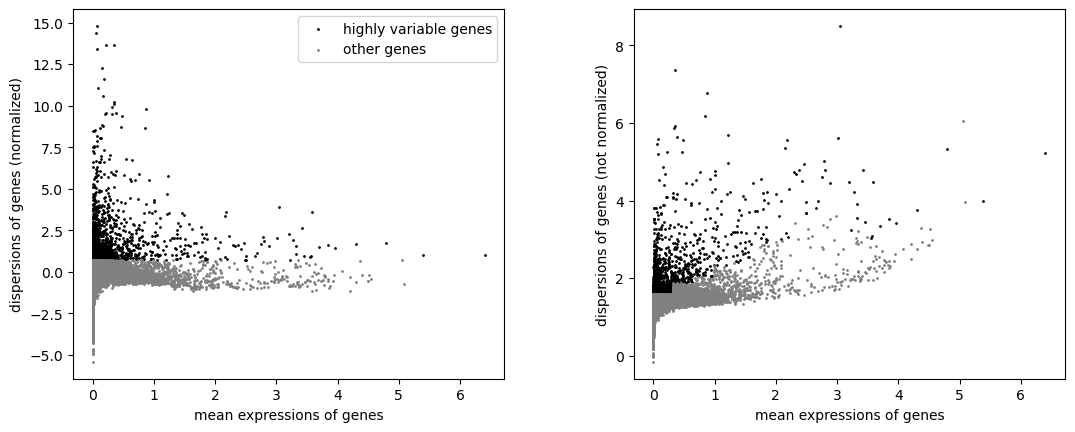

In [56]:
sc.pl.highly_variable_genes(adata)

In [57]:
adata = adata[:, adata.var.highly_variable]

In [58]:
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt', 'pct_counts_ribo'])

/home/srifai/miniconda3/envs/sc-general-analysis/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:728: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/srifai/miniconda3/envs/sc-general-analysis/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:666: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff
/home/srifai/miniconda3/envs/sc-general-analysis/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:666: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff


In [59]:
sc.pp.scale(adata, max_value=10)

In [60]:
sc.tl.pca(adata, svd_solver='arpack')

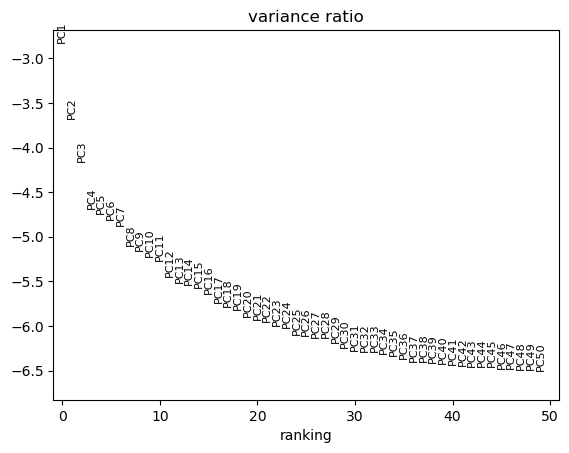

In [61]:
sc.pl.pca_variance_ratio(adata, log=True, n_pcs = 50)

In [62]:
sc.pp.neighbors(adata, n_pcs = 30)

In [63]:
sc.tl.umap(adata)

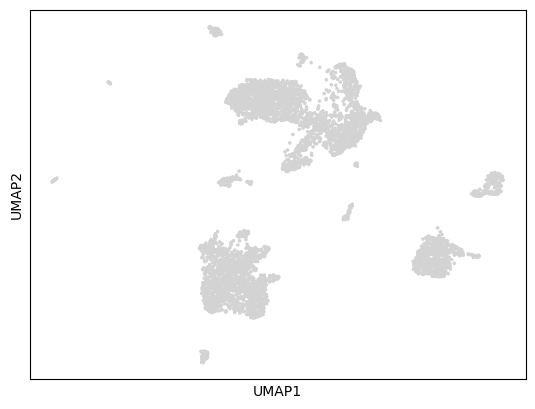

In [64]:
sc.pl.umap(adata)

In [65]:
#!pip install leidenalg

In [66]:
sc.tl.leiden(adata, resolution = 0.5)

/tmp/ipykernel_1647327/3246266323.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution = 0.5)


In [67]:
adata.obs

,doublet,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,n_genes,leiden
RCC-BM1-Tumor_AAACCTGCACCAGCAC-1,False,2027,5422.0,118.0,2.176319,1011.0,18.646257,2026,0
RCC-BM1-Tumor_AAACCTGCACGGTTTA-1,False,769,1822.0,27.0,1.481888,533.0,29.253567,769,3
RCC-BM1-Tumor_AAACCTGCATGGGACA-1,False,1063,2466.0,94.0,3.811841,431.0,17.477697,1063,1
RCC-BM1-Tumor_AAACCTGGTAGCACGA-1,False,805,2025.0,17.0,0.839506,653.0,32.246914,805,5
RCC-BM1-Tumor_AAACCTGGTATTACCG-1,False,730,1691.0,51.0,3.015967,435.0,25.724422,730,5
...,...,...,...,...,...,...,...,...,...
RCC-BM1-Tumor_TTTGTCACAGGATCGA-1,False,2282,9437.0,255.0,2.702130,2105.0,22.305819,2281,1
RCC-BM1-Tumor_TTTGTCACATTCACTT-1,False,780,1642.0,156.0,9.500609,253.0,15.408039,779,4
RCC-BM1-Tumor_TTTGTCAGTCTCTCTG-1,False,821,1649.0,20.0,1.212856,446.0,27.046696,821,0
RCC-BM1-Tumor_TTTGTCATCAGCTTAG-1,False,777,1571.0,31.0,1.973265,321.0,20.432844,776,5


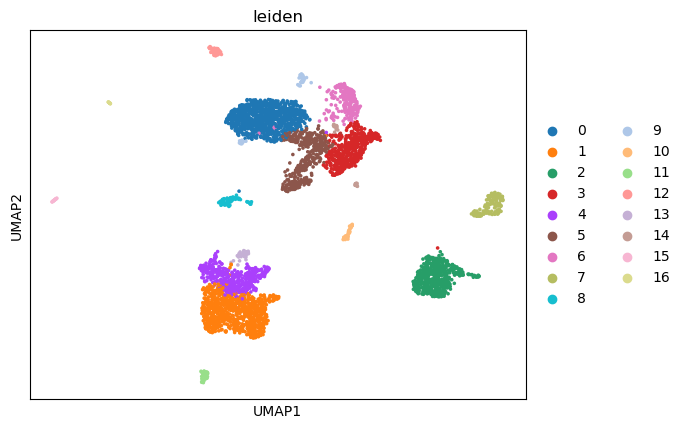

In [68]:
sc.pl.umap(adata, color=['leiden'])

# Integration

In [69]:
import os
import pandas as pd
import numpy as np

import anndata 
import scanpy as sc

import scvi
from scvi.external import SOLO

from scipy.sparse import csr_matrix



In [70]:
### establish ribo_genes
ribo_url = "http://software.broadinstitute.org/gsea/msigdb/download_geneset.jsp?geneSetName=KEGG_RIBOSOME&fileType=txt"
ribo_genes = pd.read_table(ribo_url, skiprows=2, header=None)
ribo_gene_list = ribo_genes[0].dropna().unique()
ribo_gene_list

array(['FAU', 'MRPL13', 'RPL10', 'RPL10A', 'RPL10L', 'RPL11', 'RPL12',
       'RPL13', 'RPL13A', 'RPL14', 'RPL15', 'RPL17', 'RPL18', 'RPL18A',
       'RPL19', 'RPL21', 'RPL22', 'RPL22L1', 'RPL23', 'RPL23A', 'RPL24',
       'RPL26', 'RPL26L1', 'RPL27', 'RPL27A', 'RPL28', 'RPL29', 'RPL3',
       'RPL30', 'RPL31', 'RPL32', 'RPL34', 'RPL35', 'RPL35A', 'RPL36',
       'RPL36A', 'RPL36AL', 'RPL37', 'RPL37A', 'RPL38', 'RPL39', 'RPL3L',
       'RPL4', 'RPL41', 'RPL5', 'RPL6', 'RPL7', 'RPL7A', 'RPL8', 'RPL9',
       'RPLP0', 'RPLP1', 'RPLP2', 'RPS10', 'RPS11', 'RPS12', 'RPS13',
       'RPS15', 'RPS15A', 'RPS16', 'RPS17', 'RPS18', 'RPS19', 'RPS2',
       'RPS20', 'RPS21', 'RPS23', 'RPS24', 'RPS25', 'RPS26', 'RPS27',
       'RPS27A', 'RPS27L', 'RPS28', 'RPS29', 'RPS3', 'RPS3A', 'RPS4X',
       'RPS4Y1', 'RPS5', 'RPS6', 'RPS7', 'RPS8', 'RPS9', 'RPSA',
       'RSL24D1', 'RSL24D1P11', 'UBA52'], dtype=object)

In [71]:
def pp(csv_path):
    adata = sc.read_csv(csv_path).T
    adata.var_names_make_unique()
    adata.obs_names_make_unique()
    adata.var['ribo'] = adata.var_names.isin(ribo_gene_list)
    sc.pp.filter_genes(adata, min_cells = 10)
    sc.pp.highly_variable_genes(adata, n_top_genes = 2000, subset = True, flavor = 'seurat_v3')
    scvi.model.SCVI.setup_anndata(adata)
    vae = scvi.model.SCVI(adata)
    vae.train()
    solo = scvi.external.SOLO.from_scvi_model(vae)
    solo.train()
    df = solo.predict()
    df['prediction'] = solo.predict(soft = False)
    df.index = df.index.map(lambda x: x[:-2])
    df['dif'] = df.doublet - df.singlet
    doublets = df[(df.prediction == 'doublet') & (df.dif > 1)]
    
    adata = sc.read_csv(csv_path).T
    adata.obs['Sample'] = os.path.basename(csv_path).replace('.csv', '')
    adata.obs['doublet'] = adata.obs.index.isin(doublets.index)
    adata = adata[~adata.obs.doublet]

    adata.obs_names_make_unique()
    adata.var_names_make_unique()

    sc.pp.filter_cells(adata, min_genes=200) # get rid of cells with fewer than 200 genes
    adata.var['mt'] = adata.var_names.str.startswith('mt-')  # annotate the group of mitochondrial genes as 'mt'
    adata.var['ribo'] = adata.var_names.isin(ribo_genes[0].values)
    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'ribo'], percent_top=None, log1p=False, inplace=True)
    upper_lim = np.quantile(adata.obs.n_genes_by_counts.values, .98)
    adata = adata[adata.obs.n_genes_by_counts < upper_lim]
    adata = adata[adata.obs.pct_counts_mt < 20]
    adata = adata[adata.obs.pct_counts_ribo < 100]

    # store as sparse so downstream concat stays sparse (avoids dense OOM)
    adata.X = csr_matrix(adata.X)
    return adata


In [72]:
os.listdir('Data/')

['GSM6133738_RCC-BM10-Tumor.count.csv',
 'GSM6133739_RCC-BM10-Involve.count.csv',
 'GSM6507018_BMM9-Benign-immune.count.csv',
 'GSM6133740_RCC-BM10-Noninvolved.count.csv',
 'GSM6133741_RCC-BM3-Tumor.count.csv',
 'GSM6133742_RCC-BM4-Tumor.count.csv',
 'GSM6133743_RCC-BM5-Tumor.count.csv',
 'GSM6133744_RCC-BM7-Tumor.count.csv',
 'GSM6133745_RCC-BM8-Tumor.count.csv',
 'GSM6133746_RCC-BM1-Tumor.count.csv',
 'GSM6133747_RCC-BM1-Involve.count.csv',
 'GSM6133748_RCC-BM1-Noninvolved.count.csv',
 'GSM6133749_RCC-BM2-Tumor.count.csv',
 'GSM6133750_RCC-BM2-Involve.count.csv',
 'GSM6133751_RCC-BM2-Noninvolved.count.csv',
 'GSM6133752_RCC-BM9-Involve.count.csv',
 'GSM6133753_RCC-BM9-Noninvolved.count.csv',
 'GSM6133754_RCC-BM9-Tumor.count.csv',
 'GSM6507003_BMM1-Benign-stroma.count.csv',
 'GSM6507004_BMM2-Benign-stroma.count.csv',
 'GSM6507005_BMM3-Benign-stroma.count.csv',
 'GSM6507006_BMM4-Benign-stroma.count.csv',
 'GSM6507007_BMM5-Benign-stroma.count.csv',
 'GSM6507008_BMM6-Benign-stroma.count.

In [73]:
files = ['GSM6133738_RCC-BM10-Tumor.count.csv',
 'GSM6133739_RCC-BM10-Involve.count.csv',
 'GSM6507018_BMM9-Benign-immune.count.csv',
 'GSM6133740_RCC-BM10-Noninvolved.count.csv',
 'GSM6133741_RCC-BM3-Tumor.count.csv',
 'GSM6133742_RCC-BM4-Tumor.count.csv',
 'GSM6133743_RCC-BM5-Tumor.count.csv',
 'GSM6133744_RCC-BM7-Tumor.count.csv',
 'GSM6133745_RCC-BM8-Tumor.count.csv',
 'GSM6133746_RCC-BM1-Tumor.count.csv',
 'GSM6133747_RCC-BM1-Involve.count.csv',
 'GSM6133748_RCC-BM1-Noninvolved.count.csv',
 'GSM6133749_RCC-BM2-Tumor.count.csv',
 'GSM6133750_RCC-BM2-Involve.count.csv',
 'GSM6133751_RCC-BM2-Noninvolved.count.csv',
 'GSM6133752_RCC-BM9-Involve.count.csv',
 'GSM6133753_RCC-BM9-Noninvolved.count.csv',
 'GSM6133754_RCC-BM9-Tumor.count.csv',
 'GSM6507012_BMM2-Benign-immune.count.csv',
 'GSM6507013_BMM3-Benign-immune.count.csv',
 'GSM6507014_BMM4-Benign-immune.count.csv',
 'GSM6507015_BMM5-Benign-immune.count.csv',
 'GSM6507016_BMM6-Benign-immune.count.csv',
 'GSM6507017_BMM8-Benign-immune.count.csv']

out = []

# process all samples
for file in files:
    full_path = os.path.join("Data", file)
    print(f"Adding: {file}")
    out.append(pp(full_path))

# concatenate, filter, convert to sparse, save integrated all samples
adata = sc.concat(out, join='outer')
sc.pp.filter_genes(adata, min_cells=3)
adata.X = csr_matrix(adata.X)
adata.write_h5ad("Cleaned_Data/combined.h5ad")
print("Saved combined.h5ad")

Adding: GSM6133738_RCC-BM10-Tumor.count.csv


/home/srifai/miniconda3/envs/sc-general-analysis/lib/python3.11/site-packages/scvi/dataloaders/_data_splitting.py:258: UserWarning: 1 cells moved from training set to validation set. if you want to avoid it please use train_size parameter during train.
  self.n_train, self.n_val = validate_data_split(
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/srifai/miniconda3/envs/sc-general-analysis/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/srifai/miniconda3/envs/sc-general-analysis/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_datal

Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


INFO     Creating doublets, preparing SOLO model.                                                                  


...

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/srifai/miniconda3/envs/sc-general-analysis/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/srifai/miniconda3/envs/sc-general-analysis/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=55` in the `DataLoader` to improve performance.
/home/srifai/miniconda3/envs/sc-general-analysis/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/da

Training:   0%|          | 0/400 [00:00<?, ?it/s]

Monitored metric validation_loss did not improve in the last 30 records. Best score: 0.165. Signaling Trainer to stop.


/home/srifai/miniconda3/envs/sc-general-analysis/lib/python3.11/site-packages/torch/utils/_contextlib.py:124: UserWarning: Prior to scvi-tools 1.1.3, `SOLO.predict` with `soft=True` (the default option) returned logits instead of probabilities. This behavior has since been corrected to return probabilities. The previous behavior can be replicated by passing in `return_logits=True`.
  return func(*args, **kwargs)
/home/srifai/miniconda3/envs/sc-general-analysis/lib/python3.11/site-packages/torch/utils/_contextlib.py:124: UserWarning: Prior to scvi-tools 1.1.3, `SOLO.predict` with `soft=True` (the default option) returned logits instead of probabilities. This behavior has since been corrected to return probabilities. The previous behavior can be replicated by passing in `return_logits=True`.
  return func(*args, **kwargs)
/home/srifai/miniconda3/envs/sc-general-analysis/lib/python3.11/site-packages/anndata/_core/anndata.py:639: FutureWarning: Setting element `.X` of view of `AnnData` obj

Saved combined.h5ad


In [ ]:
########################################################

In [74]:
import scanpy as sc
import scvi
import seaborn as sns
import numpy as np
import pandas as pd

In [75]:
adata = sc.read_h5ad('Cleaned_Data/combined.h5ad')
adata

AnnData object with n_obs × n_vars = 96829 × 16176
    obs: 'Sample', 'doublet', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'n_cells'

In [76]:
adata.obs.groupby('Sample').count()

/tmp/ipykernel_1647327/2340059915.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby('Sample').count()


,doublet,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo
Sample,,,,,,,,
GSM6133738_RCC-BM10-Tumor.count,4181,4181,4181,4181,4181,4181,4181,4181
GSM6133739_RCC-BM10-Involve.count,884,884,884,884,884,884,884,884
GSM6133740_RCC-BM10-Noninvolved.count,5507,5507,5507,5507,5507,5507,5507,5507
GSM6133741_RCC-BM3-Tumor.count,2292,2292,2292,2292,2292,2292,2292,2292
GSM6133742_RCC-BM4-Tumor.count,842,842,842,842,842,842,842,842
GSM6133743_RCC-BM5-Tumor.count,1350,1350,1350,1350,1350,1350,1350,1350
GSM6133744_RCC-BM7-Tumor.count,5263,5263,5263,5263,5263,5263,5263,5263
GSM6133745_RCC-BM8-Tumor.count,3991,3991,3991,3991,3991,3991,3991,3991
GSM6133746_RCC-BM1-Tumor.count,4467,4467,4467,4467,4467,4467,4467,4467


In [77]:
sc.pp.filter_genes(adata, min_cells = 100)

In [78]:
adata

AnnData object with n_obs × n_vars = 96829 × 15612
    obs: 'Sample', 'doublet', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'n_cells'

In [79]:
adata.layers['counts'] = adata.X.copy()

In [80]:
sc.pp.normalize_total(adata, target_sum = 1e4)
sc.pp.log1p(adata)
adata.raw = adata

In [81]:
adata.obs.head()

,Sample,doublet,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo
RCC-BM10-Tumor_AAACCTGAGGCCCTTG-1,GSM6133738_RCC-BM10-Tumor.count,False,630,630,1394.0,0.0,0.0,429.0,30.774748
RCC-BM10-Tumor_AAACCTGCAAGTACCT-1,GSM6133738_RCC-BM10-Tumor.count,False,708,708,1937.0,0.0,0.0,728.0,37.583893
RCC-BM10-Tumor_AAACCTGGTAGCGTGA-1,GSM6133738_RCC-BM10-Tumor.count,False,772,772,2446.0,0.0,0.0,401.0,16.394114
RCC-BM10-Tumor_AAACCTGGTTCGAATC-1,GSM6133738_RCC-BM10-Tumor.count,False,843,843,2092.0,0.0,0.0,692.0,33.078392
RCC-BM10-Tumor_AAACCTGTCTTAGCCC-1,GSM6133738_RCC-BM10-Tumor.count,False,778,778,2024.0,0.0,0.0,679.0,33.547432


In [82]:
adata

AnnData object with n_obs × n_vars = 96829 × 15612
    obs: 'Sample', 'doublet', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'n_cells'
    uns: 'log1p'
    layers: 'counts'

In [83]:
scvi.model.SCVI.setup_anndata(adata, layer = "counts",
                             categorical_covariate_keys=["Sample"],
                             continuous_covariate_keys=['pct_counts_mt', 'total_counts', 'pct_counts_ribo'])

In [84]:
model = scvi.model.SCVI(adata)

In [85]:
model.train() #may take a while without GPU

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/srifai/miniconda3/envs/sc-general-analysis/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/srifai/miniconda3/envs/sc-general-analysis/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=55` in the `DataLoader` to improve performance.


Training:   0%|          | 0/83 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=83` reached.


In [86]:
adata.obsm['X_scVI'] = model.get_latent_representation()

In [87]:
adata.layers['scvi_normalized'] = model.get_normalized_expression(library_size = 1e4)

In [88]:
sc.pp.neighbors(adata, use_rep = 'X_scVI')

In [89]:
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution = 0.5)

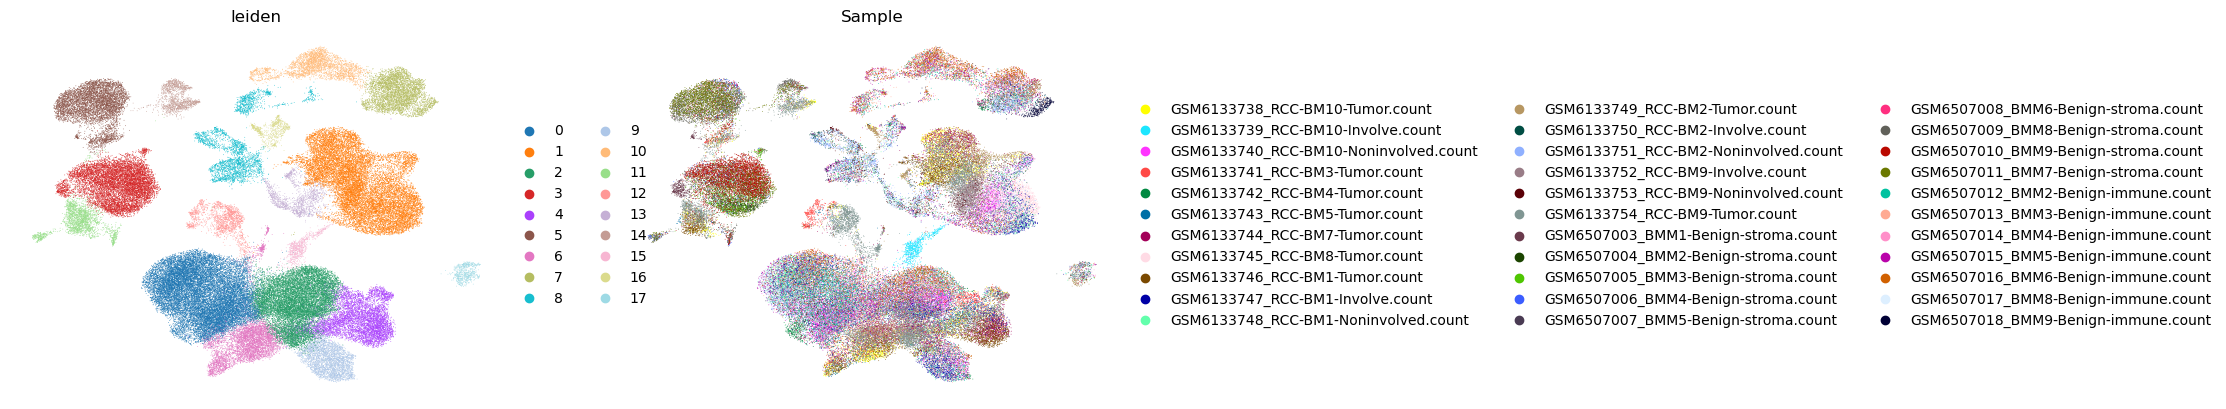

In [90]:
sc.pl.umap(adata, color = ['leiden', 'Sample'], frameon = False)

In [91]:
adata.write_h5ad('Cleaned_Data/integrated.h5ad')

# Find markers/ label cell types

In [ ]:
import scanpy as sc
import scvi
import seaborn as sns
import numpy as np
import pandas as pd

In [ ]:
adata = sc.read_h5ad('kidney-cancer/Cleaned_Data/integrated.h5ad')

In [ ]:
model = scvi.model.SCVI.load("/home/arifai/Bone-Met-Project/", adata)

INFO     No backup URL provided for missing file /home/arifai/Bone-Met-Project/model.pt                            


ValueError: Failed to load model file at /home/arifai/Bone-Met-Project/model.pt. If attempting to load a saved model from <v0.15.0, please use the util function `convert_legacy_save` to convert to an updated format.

In [ ]:
sc.tl.leiden(adata, resolution = 0.9)

/tmp/ipykernel_3031480/551005057.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution = 0.9)


In [ ]:
sc.tl.rank_genes_groups(adata, 'leiden')

/autofs/projects-t3/hussain/scProj/envs/sc-general-analysis/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/autofs/projects-t3/hussain/scProj/envs/sc-general-analysis/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/autofs/projects-t3/hussain/scProj/envs/sc-general-analysis/l

In [ ]:
#sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

In [ ]:
markers = sc.get.rank_genes_groups_df(adata, None)
markers = markers[(markers.pvals_adj < 0.05) & (markers.logfoldchanges > .5)]
markers

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,CCL5,296.665222,5.099180,0.000000,0.000000
1,0,NKG7,168.424255,4.204934,0.000000,0.000000
2,0,B2M,165.596848,1.031801,0.000000,0.000000
3,0,IL32,148.658981,2.967579,0.000000,0.000000
4,0,CST7,141.152252,3.571926,0.000000,0.000000
...,...,...,...,...,...,...
390935,25,PTPN13,2.183847,1.451803,0.030614,0.049770
390936,25,SKA2,2.183053,1.030447,0.030673,0.049851
390937,25,TGFB1I1,2.182691,1.111928,0.030700,0.049890
390938,25,NTAN1,2.182044,1.148566,0.030749,0.049960


In [ ]:
### DOWNLOADED MARKERS_SCVI
# markers_scvi = model.differential_expression(groupby = 'leiden')
# markers_scvi

In [15]:
markers_scvi = pd.read_csv('markers_scvi.csv', index_col=0)
markers_scvi

FileNotFoundError: [Errno 2] No such file or directory: 'markers_scvi.csv'

In [10]:
markers_scvi = markers_scvi[(markers_scvi['is_de_fdr_0.05']) & (markers_scvi.lfc_mean > .5)]
markers_scvi

,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,...,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05,comparison,group1,group2
EPHX2,0.9840,0.0160,4.119037,3.912544e-05,6.581296e-06,0.0,0.25,3.154921,3.242090,1.528320,...,0.156500,0.024459,0.141487,0.022749,0.516554,0.066701,True,0 vs Rest,0,Rest
RP11-641A6.2,0.9816,0.0184,3.976833,1.253433e-05,1.753723e-06,0.0,0.25,3.633432,3.715809,1.968648,...,0.026483,0.001832,0.025545,0.001664,0.086632,0.005193,True,0 vs Rest,0,Rest
MDS2,0.9794,0.0206,3.861649,3.960875e-05,6.372649e-06,0.0,0.25,3.563462,3.678632,1.946780,...,0.121676,0.014688,0.109165,0.013939,0.404058,0.048513,True,0 vs Rest,0,Rest
AC097713.4,0.9792,0.0208,3.851782,5.010327e-06,9.142001e-07,0.0,0.25,3.312922,3.229251,1.913030,...,0.010531,0.001298,0.010322,0.001298,0.035704,0.004364,True,0 vs Rest,0,Rest
CTD-2227I18.1,0.9774,0.0226,3.766946,3.154563e-06,4.696743e-07,0.0,0.25,3.256688,3.317333,1.661475,...,0.007716,0.000565,0.007716,0.000565,0.026034,0.001641,True,0 vs Rest,0,Rest
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CASS4,0.9126,0.0874,2.345802,5.496523e-06,2.892574e-06,0.0,0.25,1.410546,1.300071,1.586409,...,0.040000,0.008516,0.040000,0.008329,0.130591,0.025301,True,27 vs Rest,27,Rest
AP000251.3,0.9126,0.0874,2.345802,4.149823e-07,6.799021e-07,0.0,0.25,0.646413,0.894242,1.914432,...,0.000000,0.002239,0.000000,0.002066,0.000000,0.003136,True,27 vs Rest,27,Rest
PRMT5,0.9124,0.0876,2.343297,1.261053e-05,6.912525e-06,0.0,0.25,1.018528,1.139368,0.804083,...,0.020000,0.028053,0.020000,0.026453,0.068074,0.060655,True,27 vs Rest,27,Rest
CYP4F22,0.9124,0.0876,2.343297,2.802357e-06,1.480777e-06,0.0,0.25,1.674898,1.588486,1.719954,...,0.020000,0.002545,0.020000,0.002092,0.047699,0.006188,True,27 vs Rest,27,Rest


In [ ]:
### pre-defined labels from the annotation file; the 1,601 cells missing from it are
### filled by distance-weighted k-NN majority vote in the scVI latent space (X_scVI) --
### the standard label-transfer method (Seurat TransferData / scanpy ingest / Azimuth),
### same k=15 recipe as helper_scripts/fill_unknown_labels.py
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

ann = pd.read_csv('kidney-cancer/Cleaned_Data/cell-annotations.csv', index_col = 0)
labels = ann['celltype'].reindex(adata.obs_names).fillna('Unassigned').to_numpy()

K = 15
Z = np.asarray(adata.obsm['X_scVI'], dtype = np.float32)
query = labels == 'Unassigned'      # cells absent from the annotation file
ref = ~query                        # genuinely annotated cells = the reference

clf = KNeighborsClassifier(n_neighbors = K, weights = 'distance', n_jobs = -1)
clf.fit(Z[ref], labels[ref])
pred = clf.predict(Z[query])
conf = clf.predict_proba(Z[query]).max(axis = 1)     # vote share of the winning label

filled = labels.copy()
filled[query] = pred

adata.obs['cell label'] = pd.Categorical(filled)
adata.obs['cell_label_orig'] = pd.Categorical(labels)                    # keeps the Unassigned flag
conf_full = np.ones(len(labels), dtype = np.float32)   # annotated cells = 1.0
conf_full[query] = conf                                # transferred cells = their vote share
adata.obs['label_transfer_conf'] = conf_full

print(f"transferred {query.sum()} labels (k={K}); median confidence {np.median(conf):.2f}, "
      f"{(conf < 0.5).sum()} below 0.5; Unassigned left: {(filled == 'Unassigned').sum()}")

sc.pl.umap(adata, color = ['leiden'], frameon = False, legend_loc = "on data")
sc.pl.umap(adata, color = ['cell label'], frameon = False, legend_loc = "on data")
sc.pl.umap(adata, color = ['condition'], frameon = False, legend_loc = "on data")

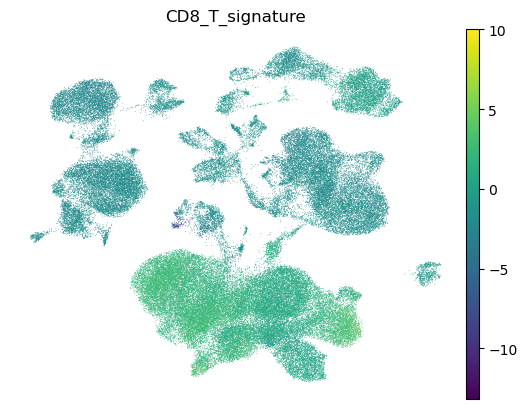

In [5]:
# sc.pl.umap(adata, color = ['LDLRAP1', 'CD8B', 'OXNAD1'], frameon = False, layer = 'scvi_normalized', vmax=10)
# #, layer = 'scvi_normalized'

import scanpy as sc

# Define your gene list
gene_list = [
    'CD8B', 'CCR7', 'CD7', 'CD3D', 'LTB', 'NOSIP', 'CD8A', 'CD3E', 'CD27',
    'IL7R', 'LDLRAP1', 'TCF7', 'LEF1', 'CD3G', 'LDHB', 'RGS10', 'PIK3IP1',
    'OXNAD1', 'ACAP1', 'ATM', 'CD48', 'TRABD2A'
]

# Compute the score from the 'scvi_normalized' layer
sc.tl.score_genes(adata, gene_list, score_name='CD8_T_signature', use_raw=False, layer='scvi_normalized')

# Plot it on the UMAP
sc.pl.umap(adata, color='CD8_T_signature', frameon=False, vmax=10, cmap='viridis')




In [6]:
markers[markers['names'].isin(['LDLRAP1', 'CD8B', 'OXNAD1'])].sort_values(by=['names', 'logfoldchanges'], ascending=[True, False])

NameError: name 'markers' is not defined

In [14]:
cell_type = {"0":"",
"1":"CD8⁺ Naive",
"2":"",
"3":"",
"4":"",
"5":"",
"6":"",
"7":"",
"8":"",
"9":"",
"10":"",
"11":"",
"12":"",
"13":"",
"14":"",
"15":"",
"16":"",
"17":"",
"18":"",
"19":"",
"20":"",
"21":"",
"22":"",
"23":"",
"24":"",
"25":"",
"26":"",
"27":"",
"28":""
}


In [15]:
adata.obs['cell type'] = adata.obs.leiden.map(cell_type)

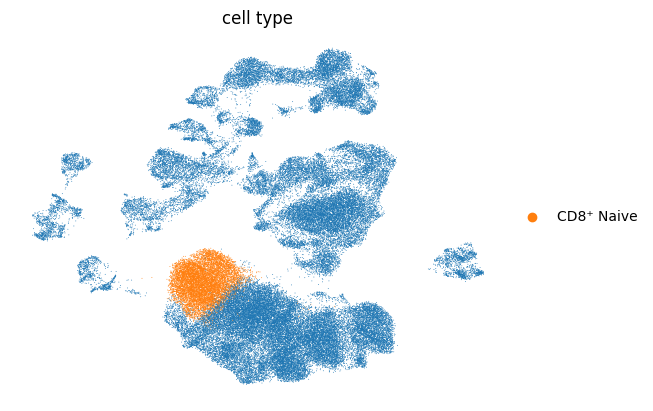

In [16]:
sc.pl.umap(adata, color = ['cell type'], frameon = False)

In [17]:
adata

AnnData object with n_obs × n_vars = 75089 × 16546
    obs: 'Sample', 'doublet', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', '_scvi_batch', '_scvi_labels', 'leiden', 'CD8_T_signature', 'cell type'
    var: 'n_cells'
    uns: 'Sample_colors', '_scvi_manager_uuid', '_scvi_uuid', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'rank_genes_groups', 'umap', 'cell type_colors'
    obsm: 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs'
    layers: 'counts', 'scvi_normalized'
    obsp: 'connectivities', 'distances'

In [18]:
adata.uns['scvi_markers'] = markers_scvi
adata.uns['markers'] = markers

In [19]:
adata.write_h5ad('integrated.h5ad')

KeyboardInterrupt: 

In [ ]:
model.save('model.model')

# Analysis

In [ ]:
import scanpy as sc
import scvi
import seaborn as sns
import numpy as np
import pandas as pd

Global seed set to 0


## Counting cells

In [ ]:
adata = sc.read_h5ad('integrated.h5ad')

In [ ]:
adata.obs.Sample.unique().tolist()

['L08cov',
 'C54ctr',
 'C53ctr',
 'L01cov',
 'L11cov',
 'C52ctr',
 'L09cov',
 'C55ctr',
 'C51ctr',
 'L16cov',
 'L07cov',
 'L04cov',
 'L12cov',
 'L06cov',
 'L17cov',
 'L18cov',
 'L15cov',
 'L05cov',
 'L13cov',
 'L19cov',
 'C57ctr',
 'L10cov',
 'L21cov',
 'L04covaddon',
 'L03cov',
 'C56ctr',
 'L22cov']

In [ ]:
def map_condition(x):
    if 'cov' in x:
        return 'COVID19'
    else:
        return 'control'

In [ ]:
adata.obs['condition'] = adata.obs.Sample.map(map_condition)
adata.obs

,Sample,doublet,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,_scvi_batch,_scvi_labels,leiden,_scvi_raw_norm_scaling,cell type,condition
TTTGACTAGAGCCGAT-1_15,L08cov,False,2576,2576,5714.0,0.0,0.0,1.0,0.017501,0,0,4,1.754386,AT1,COVID19
TTAGTCTGTATTTCCT-1_15,L08cov,False,2546,2546,5608.0,0.0,0.0,19.0,0.338802,0,0,9,1.787630,AT2,COVID19
AGGCATTCAGCTACAT-1_15,L08cov,False,2527,2527,5431.0,0.0,0.0,0.0,0.000000,0,0,15,1.843998,Airway epithelial,COVID19
GGTGATTAGAGGATCC-1_15,L08cov,False,2531,2531,5489.0,0.0,0.0,0.0,0.000000,0,0,9,1.827819,AT2,COVID19
CAGTTCCGTAGCACAG-1_15,L08cov,False,2503,2503,5446.0,0.0,0.0,10.0,0.183621,0,0,1,1.840604,Fibroblast,COVID19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCTAAGAAGTTGTCAC-1_27,L22cov,False,344,344,413.0,0.0,0.0,0.0,0.000000,0,0,1,24.213076,Fibroblast,COVID19
CGTGAATCATGTCTAG-1_27,L22cov,False,350,350,402.0,0.0,0.0,0.0,0.000000,0,0,0,24.937656,Macrophage,COVID19
GCCGATGAGTAAACGT-1_27,L22cov,False,326,326,401.0,0.0,0.0,8.0,1.995013,0,0,3,25.000000,AT2,COVID19
AGGGTGAGTATCAGGG-1_27,L22cov,False,331,331,402.0,0.0,0.0,0.0,0.000000,0,0,9,24.937656,AT2,COVID19


In [ ]:
num_tot_cells = adata.obs.groupby(['Sample']).count()
num_tot_cells = dict(zip(num_tot_cells.index, num_tot_cells.doublet))
num_tot_cells

{'C51ctr': 5414,
 'C52ctr': 4062,
 'C53ctr': 6114,
 'C54ctr': 3937,
 'C55ctr': 5107,
 'C56ctr': 3655,
 'C57ctr': 4303,
 'L01cov': 2719,
 'L03cov': 3614,
 'L04cov': 3077,
 'L04covaddon': 3947,
 'L05cov': 2451,
 'L06cov': 5716,
 'L07cov': 4335,
 'L08cov': 3480,
 'L09cov': 3135,
 'L10cov': 1343,
 'L11cov': 2481,
 'L12cov': 3230,
 'L13cov': 4305,
 'L15cov': 3578,
 'L16cov': 1608,
 'L17cov': 4020,
 'L18cov': 2425,
 'L19cov': 2151,
 'L21cov': 2964,
 'L22cov': 5808}

In [ ]:
cell_type_counts = adata.obs.groupby(['Sample', 'condition', 'cell type']).count()
cell_type_counts = cell_type_counts[cell_type_counts.sum(axis = 1) > 0].reset_index()
cell_type_counts = cell_type_counts[cell_type_counts.columns[0:4]]
cell_type_counts

,Sample,condition,cell type,doublet
0,C51ctr,control,AT1,743
1,C51ctr,control,AT2,706
2,C51ctr,control,Aerocyte,26
3,C51ctr,control,Airway epithelial,401
4,C51ctr,control,B-cell,39
...,...,...,...,...
445,L22cov,COVID19,Monocyte,127
446,L22cov,COVID19,Neuronal cell,7
447,L22cov,COVID19,Pericyte,60
448,L22cov,COVID19,Plasma cell,519


In [ ]:
cell_type_counts['total_cells'] = cell_type_counts.Sample.map(num_tot_cells).astype(int)

cell_type_counts['frequency'] = cell_type_counts.doublet / cell_type_counts.total_cells

cell_type_counts

,Sample,condition,cell type,doublet,total_cells,frequency
0,C51ctr,control,AT1,743,5414,0.137237
1,C51ctr,control,AT2,706,5414,0.130403
2,C51ctr,control,Aerocyte,26,5414,0.004802
3,C51ctr,control,Airway epithelial,401,5414,0.074067
4,C51ctr,control,B-cell,39,5414,0.007204
...,...,...,...,...,...,...
445,L22cov,COVID19,Monocyte,127,5808,0.021866
446,L22cov,COVID19,Neuronal cell,7,5808,0.001205
447,L22cov,COVID19,Pericyte,60,5808,0.010331
448,L22cov,COVID19,Plasma cell,519,5808,0.089360


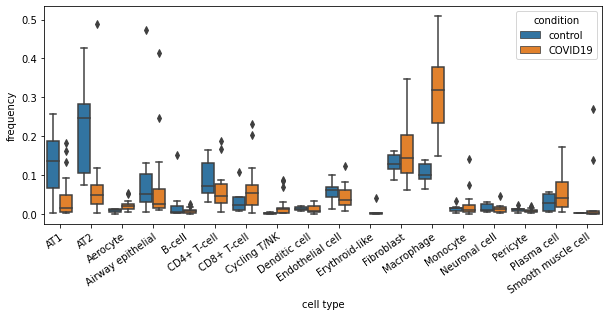

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize = (10,4))

ax = sns.boxplot(data = cell_type_counts, x = 'cell type', y = 'frequency', hue = 'condition')

plt.xticks(rotation = 35, rotation_mode = 'anchor', ha = 'right')

plt.show()


## DE

In [ ]:
subset = adata[adata.obs['cell type'].isin(['AT1', 'AT2'])].copy()

In [ ]:
#two options: SCVI or diffxpy

In [ ]:
import diffxpy.api as de

In [ ]:
subset.X = subset.X.toarray()

In [ ]:
len(subset.var)

20631

In [ ]:
subset

AnnData object with n_obs × n_vars = 17392 × 20631
    obs: 'Sample', 'doublet', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', '_scvi_batch', '_scvi_labels', 'leiden', '_scvi_raw_norm_scaling', 'cell type', 'condition'
    var: 'n_cells'
    uns: 'Sample_colors', '_scvi_manager_uuid', '_scvi_uuid', 'cell type_colors', 'leiden', 'leiden_colors', 'log1p', 'markers', 'neighbors', 'rank_genes_groups', 'scvi_markers', 'umap'
    obsm: 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs'
    layers: 'counts', 'scvi_normalized'
    obsp: 'connectivities', 'distances'

In [ ]:
sc.pp.filter_genes(subset, min_cells=100)

In [ ]:
len(subset.var)

12705

In [ ]:
subset.obs = subset.obs.rename(columns = {'cell type':'cell_type'})

In [ ]:
#subset = subset.raw.to_adata() #need to run this if you scaled/regress your data and have negative numbers


In [ ]:
subset.obs

,Sample,doublet,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,_scvi_batch,_scvi_labels,leiden,_scvi_raw_norm_scaling,cell_type,condition
TTTGACTAGAGCCGAT-1_15,L08cov,False,2576,2576,5714.0,0.0,0.0,1.0,0.017501,0,0,4,1.754386,AT1,COVID19
TTAGTCTGTATTTCCT-1_15,L08cov,False,2546,2546,5608.0,0.0,0.0,19.0,0.338802,0,0,9,1.787630,AT2,COVID19
GGTGATTAGAGGATCC-1_15,L08cov,False,2531,2531,5489.0,0.0,0.0,0.0,0.000000,0,0,9,1.827819,AT2,COVID19
GTTCCGTAGACCCGCT-1_15,L08cov,False,2295,2295,5465.0,0.0,0.0,3.0,0.054895,0,0,4,1.832845,AT1,COVID19
CAGATTGCACTAACCA-1_15,L08cov,False,2287,2287,5184.0,0.0,0.0,0.0,0.000000,0,0,4,1.932741,AT1,COVID19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AGCTTCCAGGCATGCA-1_27,L22cov,False,360,360,407.0,0.0,0.0,0.0,0.000000,0,0,9,24.570024,AT2,COVID19
GCACGGTCAGAAGTTA-1_27,L22cov,False,336,336,402.0,0.0,0.0,0.0,0.000000,0,0,9,24.937656,AT2,COVID19
TTGTGGATCATAGGCT-1_27,L22cov,False,329,329,406.0,0.0,0.0,1.0,0.246305,0,0,9,24.752476,AT2,COVID19
GCCGATGAGTAAACGT-1_27,L22cov,False,326,326,401.0,0.0,0.0,8.0,1.995013,0,0,3,25.000000,AT2,COVID19


In [ ]:
#if want to test between covid/non covid
# res = de.test.wald(data=subset,
#              formula_loc= '~ 1 + condition',
#              factor_loc_totest='condition'
#                   )


res = de.test.wald(data=subset,
             formula_loc= '~ 1 + cell_type',
             factor_loc_totest='cell_type'
                  )

/home/jrlab2019/miniconda3/envs/sc/lib/python3.9/site-packages/batchglm/models/base_glm/utils.py:110: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  np.mean(x[np.where(grouping == g)[0], :], axis=0)
/home/jrlab2019/miniconda3/envs/sc/lib/python3.9/site-packages/batchglm/models/base_glm/utils.py:158: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...

training location model: False
training scale model: True
iter   0: ll=282285631.378020
iter   1: ll=282285631.378020, converged: 0.00% (loc: 100.00%, scale update: False), in 0.00sec
iter   2: ll=69842680.056717, converged: 0.00% (loc: 0.00%, scale update: True), in 111.34sec
iter   3: ll=69842680.056717, converged: 0.00% (loc: 100.00%, scale update: False), in 0.00sec
iter   4: ll=69603570.800810, converged: 99.80% (loc: 99.80%, scale update: True), in 107.80sec
iter   5: ll=69603570.800810, converged: 99.80% (loc: 100.00%, scale update: False), in 0.00sec
iter   6: ll=69581454.822264, converged: 99.94% (loc: 99.94%, scale update: True), in 35.62sec
iter   7: ll=69581454.822264, converged: 99.94% (loc: 100.00%, scale update: False), in 0.00sec
iter   8: ll=69551673.109277, converged: 99.98% (loc: 99.98%, scale update: True), in 29.51sec
iter   9: ll=69551673.109277, converged: 99.98% (loc: 100.00%, scale update: False), in 0.00sec
iter  10: ll=69521627.923244, converged: 99.99% (loc:

/home/jrlab2019/miniconda3/envs/sc/lib/python3.9/site-packages/dask/array/core.py:3097: RuntimeWarning: divide by zero encountered in true_divide
  size = (limit / dtype.itemsize / largest_block) ** (1 / len(autos))


In [ ]:
dedf = res.summary().sort_values('log2fc', ascending = False).reset_index(drop = True)
dedf

,gene,pval,qval,log2fc,mean,zero_mean,grad,coef_mle,coef_sd,ll
0,AC018359.1,0.000000e+00,0.000000e+00,283.913085,0.014774,False,1.471862e-02,283.913085,2.222759e-162,-2038.835727
1,COL11A1,0.000000e+00,0.000000e+00,283.913085,0.018803,False,1.816848e-02,283.913085,2.222759e-162,-2527.167941
2,AC079015.1,0.000000e+00,0.000000e+00,283.913085,0.020568,False,2.069841e-02,283.913085,2.222759e-162,-2861.828587
3,LINC01584,0.000000e+00,0.000000e+00,283.913085,0.034148,False,3.242799e-02,283.913085,2.222759e-162,-4523.540856
4,AL358335.2,0.000000e+00,0.000000e+00,283.913085,0.013112,False,1.241874e-02,283.913085,2.222759e-162,-1731.587302
...,...,...,...,...,...,...,...,...,...,...
12700,AC095050.1,1.162741e-83,1.762842e-82,-6.081826,0.155194,False,1.322622e-08,-6.081826,3.138373e-01,-5165.938157
12701,SEMA3E,0.000000e+00,0.000000e+00,-297.776029,0.089118,False,1.486194e-08,-297.776029,2.222759e-162,-3373.322329
12702,LINC02814,0.000000e+00,0.000000e+00,-297.776029,0.018353,False,4.406181e-10,-297.776029,2.222759e-162,-962.055118
12703,AL807742.1,0.000000e+00,0.000000e+00,-297.776029,0.023837,False,5.994505e-10,-297.776029,2.222759e-162,-1201.275625


In [ ]:
subset.obs.cell_type.unique()

['AT1', 'AT2']
Categories (2, object): ['AT1', 'AT2']

In [ ]:
most_up = dedf.iloc[0].gene
i = np.where(subset.var_names == most_up)[0][0]

a = subset[subset.obs.cell_type == 'AT1'].X[:, i]
b = subset[subset.obs.cell_type == 'AT2'].X[:, i]
print(f"{most_up} expression:")
print(f"AT1: {a.mean()}")
print(f"AT2: {b.mean()}")


AC018359.1 expression:
AT1: 0.0
AT2: 0.02354462631046772


In [ ]:
dedf['log2fc'] = dedf['log2fc']*-1
dedf = dedf.sort_values('log2fc', ascending = False).reset_index(drop = True)
dedf

,gene,pval,qval,log2fc,mean,zero_mean,grad,coef_mle,coef_sd,ll
0,AC105914.2,0.000000e+00,0.000000e+00,297.776029,0.014490,False,1.973365e-11,-297.776029,2.222759e-162,-794.845097
1,AL807742.1,0.000000e+00,0.000000e+00,297.776029,0.023837,False,5.994505e-10,-297.776029,2.222759e-162,-1201.275625
2,LINC02814,0.000000e+00,0.000000e+00,297.776029,0.018353,False,4.406181e-10,-297.776029,2.222759e-162,-962.055118
3,SEMA3E,0.000000e+00,0.000000e+00,297.776029,0.089118,False,1.486194e-08,-297.776029,2.222759e-162,-3373.322329
4,AC095050.1,1.162741e-83,1.762842e-82,6.081826,0.155194,False,1.322622e-08,-6.081826,3.138373e-01,-5165.938157
...,...,...,...,...,...,...,...,...,...,...
12700,AC079015.1,0.000000e+00,0.000000e+00,-283.913085,0.020568,False,2.069841e-02,283.913085,2.222759e-162,-2861.828587
12701,COL11A1,0.000000e+00,0.000000e+00,-283.913085,0.018803,False,1.816848e-02,283.913085,2.222759e-162,-2527.167941
12702,AL358335.2,0.000000e+00,0.000000e+00,-283.913085,0.013112,False,1.241874e-02,283.913085,2.222759e-162,-1731.587302
12703,LGI3,0.000000e+00,0.000000e+00,-283.913085,0.021436,False,2.092837e-02,283.913085,2.222759e-162,-2906.469822


In [ ]:
dedf = dedf[(dedf.qval < 0.05) & (abs(dedf.log2fc) > .5)]
dedf

,gene,pval,qval,log2fc,mean,zero_mean,grad,coef_mle,coef_sd,ll
0,AC105914.2,0.000000e+00,0.000000e+00,297.776029,0.014490,False,1.973365e-11,-297.776029,2.222759e-162,-794.845097
1,AL807742.1,0.000000e+00,0.000000e+00,297.776029,0.023837,False,5.994505e-10,-297.776029,2.222759e-162,-1201.275625
2,LINC02814,0.000000e+00,0.000000e+00,297.776029,0.018353,False,4.406181e-10,-297.776029,2.222759e-162,-962.055118
3,SEMA3E,0.000000e+00,0.000000e+00,297.776029,0.089118,False,1.486194e-08,-297.776029,2.222759e-162,-3373.322329
4,AC095050.1,1.162741e-83,1.762842e-82,6.081826,0.155194,False,1.322622e-08,-6.081826,3.138373e-01,-5165.938157
...,...,...,...,...,...,...,...,...,...,...
12700,AC079015.1,0.000000e+00,0.000000e+00,-283.913085,0.020568,False,2.069841e-02,283.913085,2.222759e-162,-2861.828587
12701,COL11A1,0.000000e+00,0.000000e+00,-283.913085,0.018803,False,1.816848e-02,283.913085,2.222759e-162,-2527.167941
12702,AL358335.2,0.000000e+00,0.000000e+00,-283.913085,0.013112,False,1.241874e-02,283.913085,2.222759e-162,-1731.587302
12703,LGI3,0.000000e+00,0.000000e+00,-283.913085,0.021436,False,2.092837e-02,283.913085,2.222759e-162,-2906.469822


In [ ]:
dedf = dedf[dedf['mean'] > 0.15]
dedf

,gene,pval,qval,log2fc,mean,zero_mean,grad,coef_mle,coef_sd,ll
4,AC095050.1,1.162741e-83,1.762842e-82,6.081826,0.155194,False,1.322622e-08,-6.081826,0.313837,-5165.938157
7,NCKAP5-AS2,2.313156e-168,6.619064e-167,5.859465,0.273974,False,1.930704e-09,-5.859465,0.211864,-7500.659488
9,RGCC,5.424794e-217,2.051250e-215,5.321312,0.255538,False,1.417977e-09,-5.321312,0.169243,-7263.808007
13,AL355499.1,0.000000e+00,0.000000e+00,5.223264,0.561619,False,1.075236e-09,-5.223264,0.107791,-11323.233400
17,AC022325.2,0.000000e+00,0.000000e+00,4.943113,0.499731,False,9.288125e-11,-4.943113,0.100757,-10848.540222
...,...,...,...,...,...,...,...,...,...,...
12685,HHIP,3.449008e-86,5.389871e-85,-5.207289,0.260891,False,1.157253e-10,5.207289,0.264649,-8370.357374
12689,AC096531.2,5.381522e-201,1.899229e-199,-5.387216,0.679850,False,1.012193e-10,5.387216,0.178096,-15810.527889
12691,LINC01811,2.052466e-62,2.464705e-61,-5.463941,0.219332,False,3.030598e-08,5.463941,0.327708,-7109.339800
12695,PTGFR,3.909067e-69,5.104285e-68,-5.683710,0.276595,False,9.620706e-10,5.683710,0.323419,-9091.070476


In [ ]:
genes_to_show = dedf[-25:].gene.tolist() + dedf[:25].gene.tolist() #top 25 and bottom 25 from sorted df

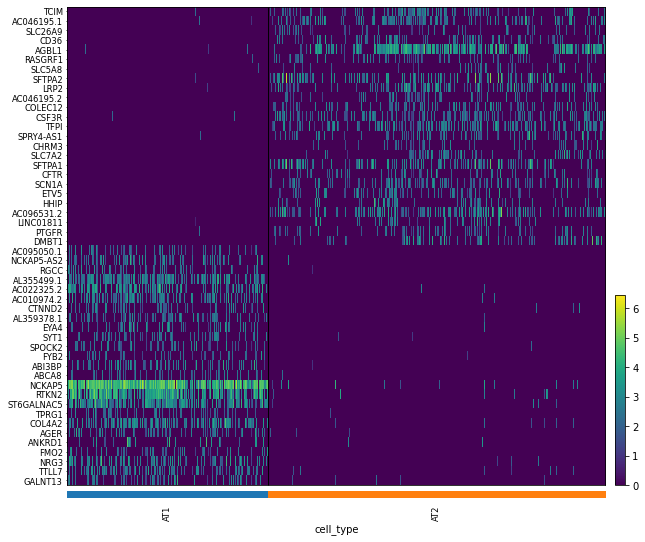

In [ ]:
sc.pl.heatmap(subset, genes_to_show, groupby='cell_type', swap_axes=True)

In [ ]:
#DE with scvi

In [ ]:
model  = scvi.model.SCVI.load('model.model', adata)

INFO     File model.model/model.pt already downloaded                                        
adfsdfsdf
adfsdfsdf
adfsdfsdf
adfsdfsdf


In [ ]:
model

SCVI Model with the following params: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, 
gene_likelihood: zinb, latent_distribution: normal
Training status: Trained

In [ ]:
scvi_de = model.differential_expression(
    idx1 = [adata.obs['cell type'] == 'AT1'],
    idx2 = [adata.obs['cell type'] == 'AT2']
    )

#any set of cells vs any set of cells
# scvi_de = model.differential_expression(
#     idx1 = [(adata.obs['cell type'].isin(['AT1', 'AT2'])) & (adata.obs.condition == 'COVID19')],
#     idx2 = [(adata.obs['cell type'].isin(['AT1', 'AT2'])) & (adata.obs.condition == 'control')]
#     )

DE...: 100%|██████████████████████████████████████| 1/1 [00:05<00:00,  5.46s/it]


In [ ]:
scvi_de

,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,lfc_min,lfc_max,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05
DMBT1,0.9982,0.0018,6.318161,0.000004,4.513010e-04,0.0,0.25,-8.036115,-8.050153,3.126623,-17.124987,3.295891,0.000772,0.652699,0.000772,0.216806,0.004793,4.311816,True
WNT3A,0.9982,0.0018,6.318161,0.000082,1.773648e-06,0.0,0.25,6.408226,6.574142,2.301937,-2.184126,12.912475,0.115296,0.002108,0.098935,0.002108,0.817271,0.011588,True
AL355499.1,0.9980,0.0020,6.212601,0.000897,1.932020e-05,0.0,0.25,6.727534,6.930730,2.437289,-4.308558,14.008843,1.323336,0.008430,0.556104,0.004307,9.164151,0.028797,True
AC105914.2,0.9980,0.0020,6.212601,0.000014,1.589177e-07,0.0,0.25,6.372631,6.558585,2.219326,-2.153578,13.018692,0.019293,0.000000,0.018521,0.000000,0.148828,0.000000,True
TTLL7,0.9978,0.0022,6.117091,0.000360,2.404536e-05,0.0,0.25,4.069274,4.183637,1.283290,-1.938815,8.505215,0.559035,0.014387,0.354839,0.012554,4.009957,0.078429,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ARID2,0.3742,0.6258,-0.514240,0.000191,1.930834e-04,0.0,0.25,-0.014206,-0.013475,0.281394,-1.349488,1.011988,0.314557,0.324474,0.246643,0.253276,2.150865,2.113666,False
SENP6,0.3694,0.6306,-0.534792,0.000317,3.276030e-04,0.0,0.25,-0.054595,-0.034585,0.296423,-2.012589,1.205351,0.472144,0.538348,0.342028,0.371667,3.274352,3.527349,False
TRIP12,0.3604,0.6396,-0.573628,0.000196,2.121055e-04,0.0,0.25,-0.115991,-0.112569,0.259490,-1.197508,0.898626,0.321503,0.357280,0.256521,0.275818,2.170178,2.294853,False
SNW1,0.3594,0.6406,-0.577969,0.000041,4.309067e-05,0.0,0.25,-0.053936,-0.056183,0.267382,-1.019018,1.037309,0.063127,0.067443,0.060040,0.062952,0.438933,0.430199,False


In [ ]:
scvi_de = scvi_de[(scvi_de['is_de_fdr_0.05']) & (abs(scvi_de.lfc_mean) > .5)]
scvi_de = scvi_de.sort_values('lfc_mean')
scvi_de

,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,lfc_min,lfc_max,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05
AC096531.2,0.9972,0.0028,5.875328,5.579448e-06,7.901783e-04,0.0,0.25,-8.643203,-9.043480,2.897235,-15.816298,3.244891,0.002933,0.997323,0.002778,0.408870,0.021904,6.957193,True
DMBT1,0.9982,0.0018,6.318161,3.602960e-06,4.513010e-04,0.0,0.25,-8.036115,-8.050153,3.126623,-17.124987,3.295891,0.000772,0.652699,0.000772,0.216806,0.004793,4.311816,True
CHI3L1,0.9942,0.0058,5.144079,6.746318e-07,3.074286e-05,0.0,0.25,-7.818566,-8.191303,3.449313,-16.311127,6.329714,0.000309,0.052232,0.000309,0.038578,0.001423,0.316771,True
SLC26A9,0.9972,0.0028,5.875328,4.452664e-06,1.697237e-04,0.0,0.25,-7.314053,-7.620886,2.954999,-14.140657,4.266300,0.003241,0.217261,0.002933,0.163750,0.021548,1.435716,True
TMEM163,0.9972,0.0028,5.875328,3.144645e-05,1.178261e-03,0.0,0.25,-7.183823,-7.374844,2.857690,-14.284339,3.777314,0.041827,1.918456,0.028245,0.650692,0.241671,13.034749,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NCKAP5,0.9972,0.0028,5.875328,7.764196e-03,1.420981e-04,0.0,0.25,6.607409,6.853317,2.110482,-2.175611,14.047405,12.053660,0.071200,0.909400,0.031889,85.427116,0.441436,True
ROR1-AS1,0.9932,0.0068,4.984008,1.136595e-04,3.062625e-06,0.0,0.25,6.704617,6.773970,3.089791,-3.487330,15.579724,0.192315,0.001191,0.133045,0.001008,1.244170,0.003307,True
AL355499.1,0.9980,0.0020,6.212601,8.970711e-04,1.932020e-05,0.0,0.25,6.727534,6.930730,2.437289,-4.308558,14.008843,1.323336,0.008430,0.556104,0.004307,9.164151,0.028797,True
LINC02814,0.9922,0.0078,4.845800,2.117875e-05,1.924546e-07,0.0,0.25,6.823726,6.673983,3.335244,-4.505098,17.230522,0.026084,0.000000,0.023152,0.000000,0.199174,0.000000,True


In [ ]:
scvi_de = scvi_de[(scvi_de.raw_normalized_mean1 > .5) | (scvi_de.raw_normalized_mean2 > .5)]
scvi_de

,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,lfc_min,lfc_max,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05
AC096531.2,0.9972,0.0028,5.875328,0.000006,0.000790,0.0,0.25,-8.643203,-9.043480,2.897235,-15.816298,3.244891,0.002933,0.997323,0.002778,0.408870,0.021904,6.957193,True
DMBT1,0.9982,0.0018,6.318161,0.000004,0.000451,0.0,0.25,-8.036115,-8.050153,3.126623,-17.124987,3.295891,0.000772,0.652699,0.000772,0.216806,0.004793,4.311816,True
SLC26A9,0.9972,0.0028,5.875328,0.000004,0.000170,0.0,0.25,-7.314053,-7.620886,2.954999,-14.140657,4.266300,0.003241,0.217261,0.002933,0.163750,0.021548,1.435716,True
TMEM163,0.9972,0.0028,5.875328,0.000031,0.001178,0.0,0.25,-7.183823,-7.374844,2.857690,-14.284339,3.777314,0.041827,1.918456,0.028245,0.650692,0.241671,13.034749,True
SFTPA2,0.9922,0.0078,4.845800,0.000031,0.000934,0.0,0.25,-6.708822,-6.964661,3.086403,-14.845112,6.670041,0.014663,1.572346,0.005093,0.311922,0.077923,9.062412,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
RTKN2,0.9946,0.0054,5.215940,0.002426,0.000066,0.0,0.25,6.590954,6.739971,2.703112,-4.828271,14.277027,3.802398,0.070558,0.702115,0.018602,27.734455,0.331616,True
NCKAP5,0.9972,0.0028,5.875328,0.007764,0.000142,0.0,0.25,6.607409,6.853317,2.110482,-2.175611,14.047405,12.053660,0.071200,0.909400,0.031889,85.427116,0.441436,True
ROR1-AS1,0.9932,0.0068,4.984008,0.000114,0.000003,0.0,0.25,6.704617,6.773970,3.089791,-3.487330,15.579724,0.192315,0.001191,0.133045,0.001008,1.244170,0.003307,True
AL355499.1,0.9980,0.0020,6.212601,0.000897,0.000019,0.0,0.25,6.727534,6.930730,2.437289,-4.308558,14.008843,1.323336,0.008430,0.556104,0.004307,9.164151,0.028797,True


In [ ]:
genes_to_show = scvi_de[-25:].index.tolist() + scvi_de[:25].index.tolist() #top 25 and bottom 25 from sorted df


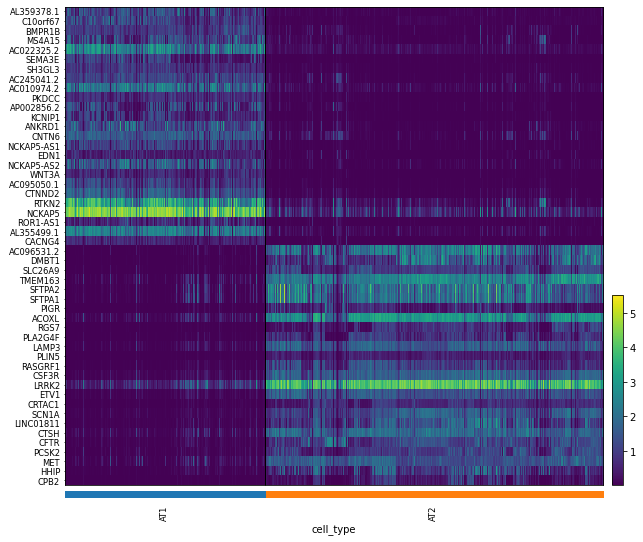

In [ ]:

sc.pl.heatmap(subset, genes_to_show, groupby='cell_type', swap_axes=True, layer = 'scvi_normalized',
              log = True)

# GO enrichment

In [ ]:
import gseapy as gp #this method requires internet connection

In [ ]:
gp.get_library_name()
# 'GO_Biological_Process_2021',
#'KEGG_2021_Human',

['ARCHS4_Cell-lines',
 'ARCHS4_IDG_Coexp',
 'ARCHS4_Kinases_Coexp',
 'ARCHS4_TFs_Coexp',
 'ARCHS4_Tissues',
 'Achilles_fitness_decrease',
 'Achilles_fitness_increase',
 'Aging_Perturbations_from_GEO_down',
 'Aging_Perturbations_from_GEO_up',
 'Allen_Brain_Atlas_10x_scRNA_2021',
 'Allen_Brain_Atlas_down',
 'Allen_Brain_Atlas_up',
 'Azimuth_Cell_Types_2021',
 'BioCarta_2013',
 'BioCarta_2015',
 'BioCarta_2016',
 'BioPlanet_2019',
 'BioPlex_2017',
 'CCLE_Proteomics_2020',
 'CORUM',
 'COVID-19_Related_Gene_Sets',
 'COVID-19_Related_Gene_Sets_2021',
 'Cancer_Cell_Line_Encyclopedia',
 'CellMarker_Augmented_2021',
 'ChEA_2013',
 'ChEA_2015',
 'ChEA_2016',
 'ChEA_2022',
 'Chromosome_Location',
 'Chromosome_Location_hg19',
 'ClinVar_2019',
 'DSigDB',
 'Data_Acquisition_Method_Most_Popular_Genes',
 'DepMap_WG_CRISPR_Screens_Broad_CellLines_2019',
 'DepMap_WG_CRISPR_Screens_Sanger_CellLines_2019',
 'Descartes_Cell_Types_and_Tissue_2021',
 'Diabetes_Perturbations_GEO_2022',
 'DisGeNET',
 'Disease_

In [ ]:
subset

AnnData object with n_obs × n_vars = 17392 × 12705
    obs: 'Sample', 'doublet', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', '_scvi_batch', '_scvi_labels', 'leiden', '_scvi_raw_norm_scaling', 'cell_type', 'condition'
    var: 'n_cells'
    uns: 'Sample_colors', '_scvi_manager_uuid', '_scvi_uuid', 'cell type_colors', 'leiden', 'leiden_colors', 'log1p', 'markers', 'neighbors', 'rank_genes_groups', 'scvi_markers', 'umap', 'cell_type_colors'
    obsm: 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs'
    layers: 'counts', 'scvi_normalized'
    obsp: 'connectivities', 'distances'

In [ ]:
enr = gp.enrichr(gene_list= dedf[dedf.log2fc > 0].gene.tolist(),
                 gene_sets=['KEGG_2021_Human','GO_Biological_Process_2021'],
                 organism='human', # don't forget to set organism to the one you desired!
                 outdir=None, # don't write to disk,
                 background = subset.var_names.tolist()
                )

/home/jrlab2019/miniconda3/envs/sc/lib/python3.9/site-packages/gseapy/enrichr.py:427: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  self.results = self.results.append(res, ignore_index=True)
/home/jrlab2019/miniconda3/envs/sc/lib/python3.9/site-packages/gseapy/enrichr.py:427: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  self.results = self.results.append(res, ignore_index=True)


In [ ]:
enr.results

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Focal adhesion,29/201,7.316495e-14,1.785225e-11,0,0,6.602599,199.702610,ITGB1;LAMA5;LAMA3;LAMC2;PIK3R1;ARHGAP5;IGF1R;E...
1,KEGG_2021_Human,Adherens junction,14/71,3.522079e-09,4.296936e-07,0,0,9.389902,182.767065,FARP2;ACTN1;LMO7;ACTN4;PTPRF;RHOA;IGF1R;TJP1;A...
2,KEGG_2021_Human,ECM-receptor interaction,14/88,6.269589e-08,5.099265e-06,0,0,7.226431,119.850144,ITGB1;LAMA5;LAMB3;ITGA3;ITGA2;LAMA3;LAMC2;HSPG...
3,KEGG_2021_Human,Tight junction,19/169,9.770140e-08,5.447448e-06,0,0,4.867223,78.563555,ITGB1;ACTN1;RDX;ACTN4;CGN;PRKCZ;RHOA;TJP1;AFDN...
4,KEGG_2021_Human,Small cell lung cancer,14/92,1.116280e-07,5.447448e-06,0,0,6.854432,109.726383,ITGB1;LAMA5;LAMB3;ITGA3;ITGA2;LAMA3;LAMC2;PIK3...
...,...,...,...,...,...,...,...,...,...,...
2894,GO_Biological_Process_2021,gene expression (GO:0010467),3/356,9.956803e-01,9.971826e-01,0,0,0.313170,0.001356,TSPAN5;BICD1;RBMS2
2895,GO_Biological_Process_2021,translation (GO:0006412),1/214,9.966190e-01,9.977464e-01,0,0,0.173601,0.000588,EEF2K
2896,GO_Biological_Process_2021,"transcription, DNA-templated (GO:0006351)",1/221,9.971957e-01,9.979474e-01,0,0,0.168016,0.000472,MED4
2897,GO_Biological_Process_2021,cellular macromolecule biosynthetic process (G...,2/314,9.977853e-01,9.981612e-01,0,0,0.236267,0.000524,EEF2K;RPA3


## comparisons

/home/jrlab2019/miniconda3/envs/sc/lib/python3.9/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value


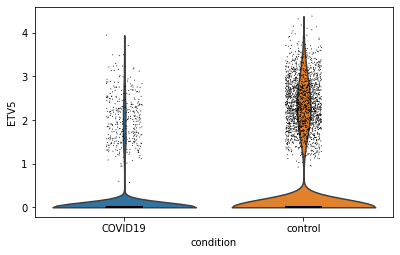

In [ ]:
sc.pl.violin(subset[subset.obs.cell_type == 'AT2'], 'ETV5', groupby='condition')

In [ ]:
from scipy import stats

In [ ]:
temp = subset[subset.obs.cell_type == 'AT2']

i = np.where(temp.var_names == 'ETV5')[0][0]

In [ ]:
a = temp[temp.obs.condition == 'COVID19'].X[:,i]
b = temp[temp.obs.condition == 'control'].X[:,i]

In [ ]:
stats.mannwhitneyu(a, b)

MannwhitneyuResult(statistic=11610070.0, pvalue=2.7473453476664947e-108)

## Score gene signature

In [ ]:
#gene signature, ie, input list of genes from user
with open('datp_sig.txt') as f:
    datp_sig = [x.strip() for x in list(f)]


In [ ]:
sc.tl.score_genes(subset, datp_sig, score_name = 'datp')

/home/jrlab2019/miniconda3/envs/sc/lib/python3.9/site-packages/scanpy/tools/_score_genes.py:151: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  for cut in np.unique(obs_cut.loc[gene_list]):


In [ ]:
subset.obs

,Sample,doublet,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,_scvi_batch,_scvi_labels,leiden,_scvi_raw_norm_scaling,cell_type,condition,datp
TTTGACTAGAGCCGAT-1_15,L08cov,False,2576,2576,5714.0,0.0,0.0,1.0,0.017501,0,0,4,1.754386,AT1,COVID19,0.149879
TTAGTCTGTATTTCCT-1_15,L08cov,False,2546,2546,5608.0,0.0,0.0,19.0,0.338802,0,0,9,1.787630,AT2,COVID19,0.462444
GGTGATTAGAGGATCC-1_15,L08cov,False,2531,2531,5489.0,0.0,0.0,0.0,0.000000,0,0,9,1.827819,AT2,COVID19,0.404560
GTTCCGTAGACCCGCT-1_15,L08cov,False,2295,2295,5465.0,0.0,0.0,3.0,0.054895,0,0,4,1.832845,AT1,COVID19,0.350152
CAGATTGCACTAACCA-1_15,L08cov,False,2287,2287,5184.0,0.0,0.0,0.0,0.000000,0,0,4,1.932741,AT1,COVID19,0.297367
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AGCTTCCAGGCATGCA-1_27,L22cov,False,360,360,407.0,0.0,0.0,0.0,0.000000,0,0,9,24.570024,AT2,COVID19,0.094823
GCACGGTCAGAAGTTA-1_27,L22cov,False,336,336,402.0,0.0,0.0,0.0,0.000000,0,0,9,24.937656,AT2,COVID19,-0.011838
TTGTGGATCATAGGCT-1_27,L22cov,False,329,329,406.0,0.0,0.0,1.0,0.246305,0,0,9,24.752476,AT2,COVID19,0.064200
GCCGATGAGTAAACGT-1_27,L22cov,False,326,326,401.0,0.0,0.0,8.0,1.995013,0,0,3,25.000000,AT2,COVID19,0.147274


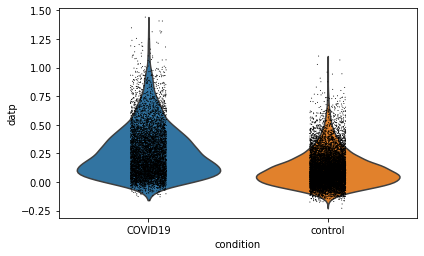

In [ ]:
sc.pl.violin(subset, 'datp', groupby='condition')

In [ ]:
a = subset[subset.obs.condition == 'COVID19'].obs.datp.values
b = subset[subset.obs.condition == 'control'].obs.datp.values
stats.mannwhitneyu(a, b)

MannwhitneyuResult(statistic=50960539.0, pvalue=0.0)

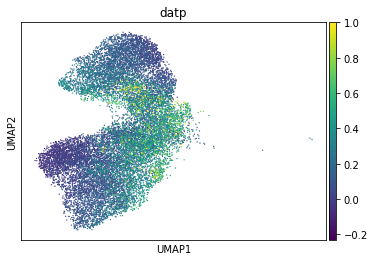

In [ ]:
sc.pl.umap(subset, color = 'datp', vmax = 1)

In [ ]:
#for thumbnail

In [ ]:
from matplotlib.pyplot import rc_context


In [ ]:
adata

AnnData object with n_obs × n_vars = 98979 × 20631
    obs: 'Sample', 'doublet', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', '_scvi_batch', '_scvi_labels', 'leiden', '_scvi_raw_norm_scaling', 'cell type'
    var: 'n_cells'
    uns: 'Sample_colors', '_scvi_manager_uuid', '_scvi_uuid', 'cell type_colors', 'leiden', 'leiden_colors', 'log1p', 'markers', 'neighbors', 'rank_genes_groups', 'scvi_markers', 'umap'
    obsm: 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs'
    layers: 'counts', 'scvi_normalized'
    obsp: 'connectivities', 'distances'

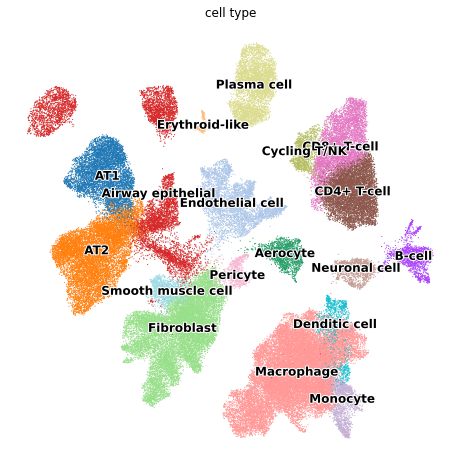

In [ ]:
with rc_context({'figure.figsize': (8,8)}):
    sc.pl.umap(adata, color = ['cell type'], frameon = False, s = 5, legend_loc = 'on data',
              legend_fontsize=12, legend_fontoutline=2)

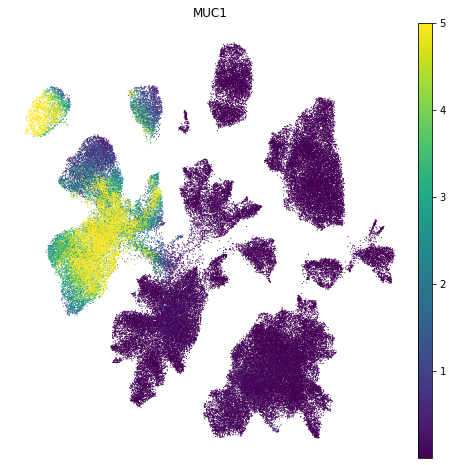

In [ ]:
with rc_context({'figure.figsize': (8,8)}):
    sc.pl.umap(adata, color = ['MUC1'], frameon = False, layer = 'scvi_normalized', vmax = 5, s = 5)